# Recurrent Neural Networks
https://github.com/saqemlas/deep-learning-specialization/blob/main/5_SequenceModels/week_1/Assignment/Building_a_Recurrent_Neural_Network_Step_by_Step.ipynb

In [ ]:
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense

In [ ]:
max_features = 10000 # Number of words to consider as features
maxlen = 500 # Cuts off texts after this number of words (among the max_features most common words)
batch_size = 32 

In [ ]:
start_char = 1
oov_char = 2 # Out of vocabulary character
index_from = 3 # Index actual words with this index and higher

In [ ]:
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features, maxlen=maxlen)#, start_char=start_char, oov_char=oov_char, index_from=index_from)
# Load training and test data, keeping only the top max_features most frequent words, and cutting off texts after maxlen words (among the max_features most common words)

In [ ]:
input_train[3:]

In [ ]:
len(input_train[3])

In [ ]:
input_train.max()

In [ ]:
word_index = imdb.get_word_index()
word_index

In [ ]:
# Reverse the word index to obtain a dict mapping indices to words
# And add 'index_from' to indices to sync with 'x_train'
inverted_word_index = dict((i + index_from, word) for (word, i) in word_index.items())

# Update inverted_word_index to include 'start_char and oov_char
inverted_word_index[start_char] = "[START]"
inverted_word_index[oov_char] = "[OOV]"
# Decode the first sequence in the dataset
decoded_sequence = ' '.join(inverted_word_index[i] for i in input_train[3])
decoded_sequence

In [ ]:
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)
# Use beforehand selected maximum length to the consequent data of the training and test sets. Sequences longer than this will be truncated, and sequences shorter will be padded with zeros at the beginning.

In [ ]:
input_train[3:]

In [ ]:
len(input_train[0])

In [ ]:
input_train[3]

In [ ]:
model = Sequential()
# Create empty Sequential model

# Add an Embedding layer for words conversion with the following arguments:
# - max_features: the size of the vocabulary, i.e. maximum integer index + 1
# - 32: the dimension of the dense embedding

# Add Empbedding layer for words conversion 
model.add(Embedding(max_features, 32))
# Parameter: number of words to consider as features (vocabulary size), dimension of the dense embedding (size of the embedding vector for each word)



# Add SimpleRNN layer with 32 units
model.add(SimpleRNN(32))
# Parameter: number of units (size of the hidden state)



# Add a Dense classifier on top with a single unit and sigmoid activation
model.add(Dense(1, activation='sigmoid'))
# Parameters: number of units (output dimension), activation function (sigmoid for binary classification)

In [ ]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.build(input_shape=(None, maxlen))

In [ ]:
model.summary()

In [ ]:
# len(model.layers[0].weights[0][0])
model.layers[0].weights[0][0] # one vector of length 32 per word -> this is learnt

In [ ]:
history = model.fit(input_train, y_train, epochs=5, batch_size=128, validation_split=0.3)
# Launch model learning for train data and 5 epochs, with a batch size of 128, and using 30% of the data for validation. Store training history in 'history' variable.

In [ ]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# Embedding
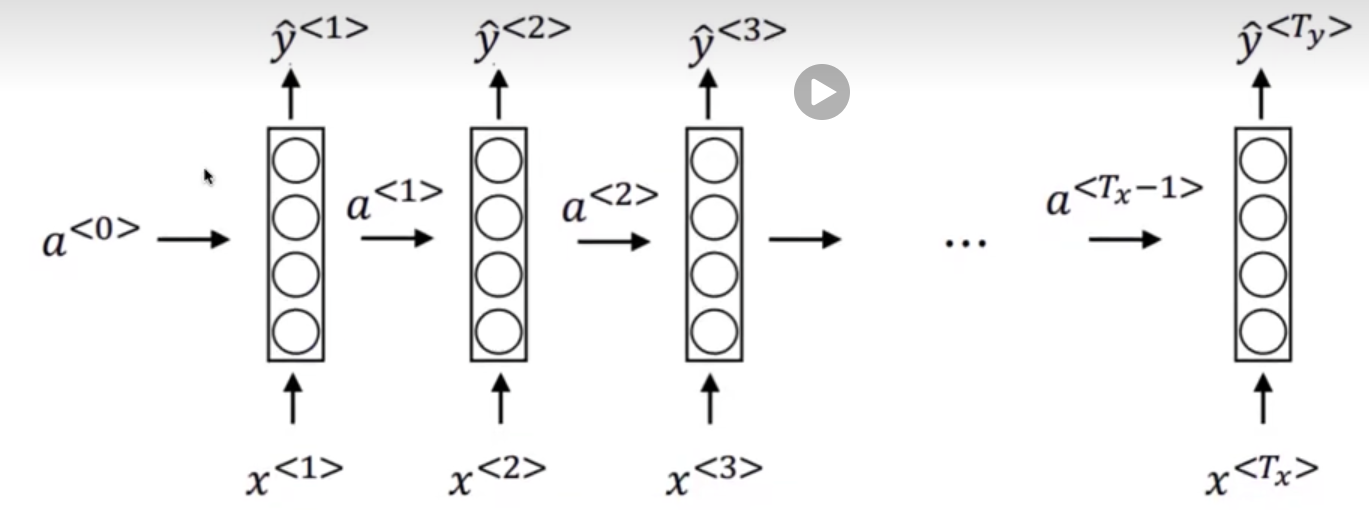

In [ ]:
# Let's take a detailed look at how the Embedding layer and the SimpleRNN layer can be implemented
import numpy as np

# Custom implementation of the Embedding layer
class CustomEmbedding:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        # Initialize the embedding matrix with random values
        self.embeddings_matrix = np.random.randn(input_dim, output_dim)

    def forward(self, input_indices):
        # Retrieve embeddings for the input sequence of word indices
        embeddings = [self.embeddings_matrix[word_index] for word_index in input_indices]
        return np.array(embeddings)

# RNN and hidden layers

## Sequence classification

In [ ]:
class CustomSimpleRNN:
    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        # Initialize weights for the inpout-to_hidden and hidden-to-hidden connections, and the bias
        self.Wx = np.random.randn(input_dim, hidden_dim)  # Weights for input
        self.Wh = np.random.randn(hidden_dim, hidden_dim)  # Weights for hidden state
        self.b = np.zeros((1, hidden_dim,))  # Bias
        # Initialize the hidden state to None
        self.h = None   

    def forward(self, input_sequence):
        # 
        self.h = np.zeros((1, self.hidden_dim))  # Initial hidden state
        # Iterate through each time step in the input sequence
        for input_t in input_sequence:
            self.h = np.tanh(np.dot(input_t, self.Wx) + np.dot(self.h, self.Wh) + self.b)
        return self.h

In [ ]:
# Custom implementation of the Dense layer - for a sequence classification task
class CustomDense:
    def __init__(self, input_dim, output_dim, activation):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation

        # Initialize weights and bias for the dense layer
        self.W = np.random.randn(input_dim, output_dim)  # Weights
        self.b = np.zeros((1, output_dim))  # Bias

    def forward(self, input_vector):
        # Compute the output of the dense layer using a linear transformation followed by the specified activation function
        z = np.dot(input_vector, self.W) + self.b  # Linear transformation
        if self.activation == 'sigmoid':
            output = 1 / (1 + np.exp(-z))  # Sigmoid activation function
        elif self.activation == 'relu':
            output = np.maximum(0, z)  # ReLU activation function       
        
        return output

In [ ]:
# Instantiate the custom layers
custom_embedding_layer = CustomEmbedding(input_dim=max_features, output_dim=32)
custom_simple_rnn_layer = CustomSimpleRNN(input_dim=32, hidden_dim=32)
custom_dense_layer = CustomDense(input_dim=32, output_dim=1, activation='sigmoid')

In [ ]:
input_train[0]

In [ ]:
# Forward pass through cutom layers for the first training example

embedded_sequence = custom_embedding_layer.forward(input_train[0])  # Get the embeddings for the input sequence
len(embedded_sequence)  # Length of the embedded sequence (should be maxlen) each word incoded into a 32-element vector

In [ ]:
rnn_output = custom_simple_rnn_layer.forward(embedded_sequence)  # Get the output of the SimpleRNN layer
rnn_output

In [ ]:
predictions = custom_dense_layer.forward(rnn_output)  # Get the final prediction from the Dense layer
predictions

In [ ]:
loss = predictions - y_train[0]  # Compute a simple loss (difference between prediction and true label)
loss[0]

In [ ]:
custom_simple_rnn_layer.Wh

# Token classification

In [ ]:
import numpy as np
# For comparison

class CustomSimpleRNN: